# Kinodynamic Diffusion Planner
## Diffusion Models for Kinodynamic Constraint Satisfaction

**Complete Implementation in Google Colab**

This notebook implements a trajectory planning system that:
1. Learns to generate control sequences using diffusion models
2. Enforces kinodynamic constraints via proximal projection
3. Guarantees obstacle avoidance using signed distance fields

Dataset generated using the **DiffDrive dataset pipeline** (unicycle dynamics,
diverse map types: clutter, corridor, doorway, parking, open).

---

### 📋 Sections:
1. **Setup & Installation**
2. **Module 1: Dynamics** - Differentiable forward simulation (incl. Unicycle)
3. **Module 2: Diffusion Model** - Temporal U-Net for control sequences
4. **Module 3: Constraints** - Grid SDF + Proximal Projection
5. **Module 4: Dataset** - DiffDrive dataset pipeline + loader
6. **Dataset Generation** - Generate & save npz dataset
7. **Training** - Train the diffusion model
8. **Evaluation** - Test with constraint projection
9. **Visualizations** - Compare results
10. **Ablation Studies** - Systematic experiments

**⚡ Quick Start:** Run all cells in order!


---
## 1. Setup & Installation

In [28]:
# Install required packages
!pip install torch torchvision torchaudio --quiet
!pip install matplotlib tqdm pandas --quiet

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrow
from matplotlib.animation import FuncAnimation
from tqdm.notebook import tqdm as tqdm_nb
from tqdm import tqdm
import math, os, json, random, glob, time, pickle
from dataclasses import dataclass, asdict, field
from typing import Dict, List, Optional, Tuple

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

print("\n✓ Setup complete!")


Using device: cuda
GPU: Tesla T4
Memory: 15.64 GB

✓ Setup complete!


---
## 2. Module 1: Dynamics

Implements differentiable dynamics for trajectory rollout.

**Key Classes:**
- `BaseDynamics`: Abstract dynamics interface
- `SingleIntegrator2D`: Simple position control (state=[x,y], control=[vx,vy])
- `PointMass2D`: With velocity dynamics (state=[x,y,vx,vy], control=[ax,ay])
- `UnicycleDynamics`: Unicycle model (state=[x,y,theta], control=[v,w]) — **used with DiffDrive dataset**
- `DifferentiableRollout`: Rolls out controls through dynamics with gradient flow


In [29]:
class BaseDynamics(nn.Module):
    """Abstract base class for dynamics models"""

    def __init__(self, state_dim, control_dim, dt=0.1):
        super().__init__()
        self.state_dim = state_dim
        self.control_dim = control_dim
        self.dt = dt

    def forward(self, x, u):
        raise NotImplementedError


class PointMass2D(BaseDynamics):
    """2D point mass with velocity: state=[x,y,vx,vy], control=[ax,ay]"""

    def __init__(self, dt=0.1, max_velocity=2.0, damping=0.9):
        super().__init__(state_dim=4, control_dim=2, dt=dt)
        self.max_velocity = max_velocity
        self.damping = damping

    def forward(self, x, u):
        pos = x[..., :2]
        vel = x[..., 2:]
        vel_new = self.damping * vel + self.dt * u
        vel_new = torch.clamp(vel_new, -self.max_velocity, self.max_velocity)
        pos_new = pos + self.dt * vel_new
        return torch.cat([pos_new, vel_new], dim=-1)


class SingleIntegrator2D(BaseDynamics):
    """Simple velocity control: state=[x,y], control=[vx,vy]"""

    def __init__(self, dt=0.1):
        super().__init__(state_dim=2, control_dim=2, dt=dt)

    def forward(self, x, u):
        return x + self.dt * u


class UnicycleDynamics(BaseDynamics):
    """
    Unicycle model: state=[x, y, theta], control=[v, w].
    Used together with the DiffDrive dataset generated by dataset.py.
    """

    def __init__(self, dt=0.1, v_max=2.8, v_min=-0.2, w_max=1.5):
        super().__init__(state_dim=3, control_dim=2, dt=dt)
        self.v_max = v_max
        self.v_min = v_min
        self.w_max = w_max

    def forward(self, x, u):
        pos   = x[..., :2]           # [*, 2]
        theta = x[..., 2:3]          # [*, 1]

        v = torch.clamp(u[..., 0:1], self.v_min, self.v_max)
        w = torch.clamp(u[..., 1:2], -self.w_max, self.w_max)

        dx = v * torch.cos(theta)
        dy = v * torch.sin(theta)
        new_pos   = pos + self.dt * torch.cat([dx, dy], dim=-1)
        new_theta = theta + self.dt * w
        # Wrap angle to (-pi, pi]
        new_theta = torch.atan2(torch.sin(new_theta), torch.cos(new_theta))
        return torch.cat([new_pos, new_theta], dim=-1)


class DifferentiableRollout(nn.Module):
    """Roll out controls through dynamics (enables backprop)"""

    def __init__(self, dynamics):
        super().__init__()
        self.dynamics = dynamics

    def forward(self, x0, controls):
        batch_size, T = controls.shape[:2]
        state_dim = self.dynamics.state_dim
        states = torch.zeros(batch_size, T + 1, state_dim,
                             device=x0.device, dtype=x0.dtype)
        states[:, 0] = x0
        x = x0
        for t in range(T):
            x = self.dynamics(x, controls[:, t])
            states[:, t + 1] = x
        return states


# ── normalisation helpers (used throughout) ─────────────────────────────────
MAP_SIZE_M = 10.0          # dataset map size (metres)
V_MEAN, V_HALF = 1.3, 1.5  # centring for v in [-0.2, 2.8]
W_MAX = 1.5                # angular rate bound
ROBOT_RADIUS = 0.20        # metres
SAFETY_MARGIN = 0.05       # metres
DELTA = ROBOT_RADIUS + SAFETY_MARGIN  # SDF threshold for collision penalty


def norm_ctrl(u: torch.Tensor) -> torch.Tensor:
    """Physical controls [v, w] → normalised ≈ [-1, 1]^2."""
    v_n = (u[..., :1] - V_MEAN) / V_HALF
    w_n = u[..., 1:2] / W_MAX
    return torch.cat([v_n, w_n], dim=-1)


def denorm_ctrl(u_n: torch.Tensor) -> torch.Tensor:
    """Normalised controls → physical [v, w]."""
    v = u_n[..., :1] * V_HALF + V_MEAN
    w = u_n[..., 1:2] * W_MAX
    return torch.cat([v, w], dim=-1)


def norm_state(x: torch.Tensor) -> torch.Tensor:
    """Physical state [x,y,theta] → normalised [x/10, y/10, theta/pi]."""
    pos = x[..., :2] / MAP_SIZE_M
    th  = x[..., 2:3] / math.pi
    return torch.cat([pos, th], dim=-1)


# ── Quick tests ───────────────────────────────────────────────────────────────
print("Testing UnicycleDynamics ...")
dyn = UnicycleDynamics(dt=0.1)
ro  = DifferentiableRollout(dyn)
x0  = torch.tensor([[1.0, 1.0, 0.0]]).expand(2, -1)
u   = torch.zeros(2, 20, 2); u[:, :, 0] = 1.0  # constant forward
states = ro(x0, u)
print(f"  Rollout shape: {states.shape}  (batch=2, T+1=21, state_dim=3)")
print(f"  Final x: {states[0, -1, 0]:.2f} (expected ≈3.0)")

u_phys = torch.tensor([[1.5, 0.5]])
u_norm = norm_ctrl(u_phys)
print(f"  Normalisation round-trip: {torch.allclose(denorm_ctrl(u_norm), u_phys)}")
print("✓ Dynamics OK")


Testing UnicycleDynamics ...
  Rollout shape: torch.Size([2, 21, 3])  (batch=2, T+1=21, state_dim=3)
  Final x: 3.00 (expected ≈3.0)
  Normalisation round-trip: True
✓ Dynamics OK


---
## 3. Module 2: Diffusion Model

Temporal U-Net for denoising control sequences + DDPM/DDIM implementation.

**Architecture:**
- Sinusoidal time embeddings for diffusion step k
- 1D temporal convolutions with U-Net skip connections
- FiLM conditioning on time + task condition (x0_norm, xgoal_norm, map_emb)


In [30]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = t[:, None] * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)


class TemporalConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, padding=kernel_size // 2)
        self.norm = nn.GroupNorm(min(8, out_channels), out_channels)
        self.act  = nn.Mish()

    def forward(self, x):
        return self.act(self.norm(self.conv(x)))


class TemporalUNet(nn.Module):
    """
    Temporal U-Net for denoising control sequences.
    Condition embedding is injected at every encoder/bottleneck resolution (FiLM additive bias).
    cond_dim must match the actual condition vector passed in at runtime.
    """

    def __init__(self, control_dim, hidden_dim=128, time_emb_dim=64, cond_dim=38):
        super().__init__()
        self.control_dim = control_dim

        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            nn.Mish(),
            nn.Linear(time_emb_dim * 4, time_emb_dim),
        )
        self.cond_encoder = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            nn.Mish(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        # Encoder
        self.enc1 = TemporalConvBlock(control_dim, hidden_dim // 2)
        self.enc2 = TemporalConvBlock(hidden_dim // 2, hidden_dim)
        self.enc3 = TemporalConvBlock(hidden_dim, hidden_dim * 2)

        # Bottleneck
        self.bottleneck = TemporalConvBlock(hidden_dim * 2, hidden_dim * 2)

        # Decoder
        self.dec3 = TemporalConvBlock(hidden_dim * 4, hidden_dim)
        self.dec2 = TemporalConvBlock(hidden_dim * 2, hidden_dim // 2)
        self.dec1 = TemporalConvBlock(hidden_dim, hidden_dim // 2)

        self.out = nn.Conv1d(hidden_dim // 2, control_dim, 1)

        self.time_mod = nn.ModuleList([
            nn.Linear(time_emb_dim, hidden_dim // 2),
            nn.Linear(time_emb_dim, hidden_dim),
            nn.Linear(time_emb_dim, hidden_dim * 2),
            nn.Linear(time_emb_dim, hidden_dim * 2),
        ])
        self.cond_mod = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.Linear(hidden_dim, hidden_dim * 2),
        ])

    def forward(self, u_noisy, k, condition):
        x     = u_noisy.transpose(1, 2)          # [B, C, T]
        t_emb = self.time_mlp(k.float())          # [B, time_emb_dim]
        c_emb = self.cond_encoder(condition)      # [B, hidden_dim]

        e1 = self.enc1(x)     + self.time_mod[0](t_emb)[:,:,None] + self.cond_mod[0](c_emb)[:,:,None]
        e2 = self.enc2(F.avg_pool1d(e1, 2)) + self.time_mod[1](t_emb)[:,:,None] + self.cond_mod[1](c_emb)[:,:,None]
        e3 = self.enc3(F.avg_pool1d(e2, 2)) + self.time_mod[2](t_emb)[:,:,None] + self.cond_mod[2](c_emb)[:,:,None]
        b  = self.bottleneck(F.avg_pool1d(e3, 2)) + self.time_mod[3](t_emb)[:,:,None] + self.cond_mod[3](c_emb)[:,:,None]

        d3 = self.dec3(torch.cat([F.interpolate(b,  size=e3.shape[-1], mode='linear', align_corners=False), e3], dim=1))
        d2 = self.dec2(torch.cat([F.interpolate(d3, size=e2.shape[-1], mode='linear', align_corners=False), e2], dim=1))
        d1 = self.dec1(torch.cat([F.interpolate(d2, size=e1.shape[-1], mode='linear', align_corners=False), e1], dim=1))

        return self.out(d1).transpose(1, 2)       # [B, T, C]


class ControlDiffusion(nn.Module):
    """DDPM for control sequences (normalised controls ≈ N(0,1) range)."""

    def __init__(self, denoiser, T_diffusion=50, beta_schedule='cosine'):
        super().__init__()
        self.denoiser   = denoiser
        self.T_diffusion = T_diffusion

        if beta_schedule == 'linear':
            betas = torch.linspace(1e-4, 0.02, T_diffusion)
        else:
            s     = 0.008
            steps = T_diffusion + 1
            x     = torch.linspace(0, T_diffusion, steps)
            abar  = torch.cos(((x / T_diffusion) + s) / (1 + s) * math.pi * 0.5) ** 2
            abar  = abar / abar[0]
            betas = torch.clamp(1 - abar[1:] / abar[:-1], 0, 0.999)

        alphas       = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)

        self.register_buffer('betas', betas)
        self.register_buffer('alphas', alphas)
        self.register_buffer('alphas_cumprod', alphas_cumprod)
        self.register_buffer('sqrt_alphas_cumprod',       torch.sqrt(alphas_cumprod))
        self.register_buffer('sqrt_one_minus_alphas_cumprod', torch.sqrt(1.0 - alphas_cumprod))

    def q_sample(self, u0, k, noise=None):
        if noise is None:
            noise = torch.randn_like(u0)
        u_k = self.sqrt_alphas_cumprod[k][:,None,None] * u0 \
            + self.sqrt_one_minus_alphas_cumprod[k][:,None,None] * noise
        return u_k, noise

    def p_sample(self, u_t, t, condition):
        eps       = self.denoiser(u_t, t, condition)
        abar_t    = self.alphas_cumprod[t][:,None,None]
        alpha_t   = self.alphas[t][:,None,None]
        beta_t    = self.betas[t][:,None,None]
        u0_hat    = (u_t - torch.sqrt(1.0 - abar_t) * eps) / torch.sqrt(abar_t)
        abar_prev = torch.where((t > 0)[:,None,None],
                                self.alphas_cumprod[(t-1).clamp(min=0)][:,None,None],
                                torch.ones_like(abar_t))
        beta_tilde = beta_t * (1.0 - abar_prev) / (1.0 - abar_t)
        sigma      = torch.sqrt(beta_tilde)
        coef1      = torch.sqrt(abar_prev) * beta_t / (1.0 - abar_t)
        coef2      = torch.sqrt(alpha_t) * (1.0 - abar_prev) / (1.0 - abar_t)
        mu         = coef1 * u0_hat + coef2 * u_t
        return mu + (t > 0)[:,None,None].float() * sigma * torch.randn_like(u_t)

    def p_sample_ddim(self, u_t, t, condition, eta=0.0):
        eps       = self.denoiser(u_t, t, condition)
        abar_t    = self.alphas_cumprod[t][:,None,None]
        alpha_t   = self.alphas[t][:,None,None]
        u0_hat    = (u_t - torch.sqrt(1.0 - abar_t) * eps) / torch.sqrt(abar_t)
        abar_prev = torch.where((t > 0)[:,None,None],
                                self.alphas_cumprod[(t-1).clamp(min=0)][:,None,None],
                                torch.ones_like(abar_t))
        sigma       = eta * torch.sqrt((1.0 - abar_prev) / (1.0 - abar_t) * (1.0 - alpha_t))
        eps_coeff   = torch.sqrt(torch.clamp(1.0 - abar_prev - sigma**2, min=0.0))
        u_prev      = (torch.sqrt(abar_prev) * u0_hat + eps_coeff * eps
                       + (t > 0)[:,None,None].float() * sigma * torch.randn_like(u_t))
        return u_prev

    @torch.no_grad()
    def sample(self, shape, condition, method='ddim', eta=0.0):
        device = self.betas.device
        u = torch.randn(shape, device=device)
        for i in reversed(range(self.T_diffusion)):
            t = torch.full((shape[0],), i, device=device, dtype=torch.long)
            u = self.p_sample(u, t, condition) if method.lower() == 'ddpm' \
                else self.p_sample_ddim(u, t, condition, eta=eta)
        return u


print("✓ Diffusion model defined")


✓ Diffusion model defined


---
## 4. Module 3: Constraints

**Signed Distance Field (SDF)** for obstacles + **Proximal Projection** for feasibility.

Two SDF backends:
- `SignedDistanceField2D` — analytic circle SDF (kept for backward compat)
- `GridSDF2D` — differentiable bilinear interpolation on the per-sample 64×64 grid from the dataset

Key idea: after each denoising step, solve
```
u* = argmin ||u - ũ||² + λ Φ(u)
```
where Φ penalises goal error, collisions, and control effort.
Projection operates on **physical (denormalised) controls**.


In [31]:
# ── Analytic SDF (kept for reference / backward compat) ─────────────────────
class SignedDistanceField2D(nn.Module):
    def __init__(self, obstacles, grid_size=100, bounds=(-1, 1), precompute_grid=True):
        super().__init__()
        self.obstacles = obstacles
        centers = torch.tensor([c for (c, r) in obstacles], dtype=torch.float32)
        radii   = torch.tensor([r for (c, r) in obstacles], dtype=torch.float32)
        self.register_buffer('centers', centers)
        self.register_buffer('radii',   radii)
        self.sdf_grid = self._compute_sdf_grid() if precompute_grid else None

    def _compute_sdf_grid(self):
        from matplotlib.patches import Circle as _C  # local import guard
        x = torch.linspace(self.bounds[0] if hasattr(self,'bounds') else -1,
                           1, 100)
        y = torch.linspace(-1, 1, 100)
        xx, yy = torch.meshgrid(x, y, indexing='ij')
        pts = torch.stack([xx, yy], dim=-1)
        return self(pts)

    def forward(self, positions):
        pos     = positions
        centers = self.centers.to(pos.device, dtype=pos.dtype)
        radii   = self.radii.to(pos.device,   dtype=pos.dtype)
        diff    = pos[..., None, :] - centers
        dist    = torch.sqrt(torch.sum(diff * diff, dim=-1) + 1e-9)
        return torch.min(dist - radii, dim=-1).values


# ── Grid SDF (per-sample, differentiable via bilinear interp) ───────────────
class GridSDF2D(nn.Module):
    """
    Differentiable SDF query on a per-sample occupancy/SDF grid.
    Uses F.grid_sample (bilinear, differentiable) so gradients flow back to positions.

    Convention:
      sdf_grid[b, r, c] corresponds to world (x = c/grid_size * map_size,
                                               y = r/grid_size * map_size).
    """

    def __init__(self, map_size_m: float = MAP_SIZE_M):
        super().__init__()
        self.map_size_m = map_size_m

    def forward(self, sdf_grid: torch.Tensor, positions: torch.Tensor) -> torch.Tensor:
        """
        Args:
            sdf_grid : [B, H, W]  float32  (raw SDF in metres)
            positions: [B, ..., 2] world coordinates in [0, map_size_m]
        Returns:
            [B, ...] SDF values in metres
        """
        B        = sdf_grid.shape[0]
        orig     = positions.shape          # [B, ..., 2]
        pos_flat = positions.reshape(B, -1, 2)  # [B, N, 2]

        # Normalise world→ grid_sample coords in [-1, 1]
        xn = 2.0 * pos_flat[..., 0] / self.map_size_m - 1.0
        yn = 2.0 * pos_flat[..., 1] / self.map_size_m - 1.0
        grid = torch.stack([xn, yn], dim=-1).unsqueeze(2)  # [B, N, 1, 2]

        # F.grid_sample: input [B,1,H,W], grid [B,N,1,2] → [B,1,N,1]
        out = F.grid_sample(
            sdf_grid.unsqueeze(1).float(),
            grid, mode='bilinear', align_corners=True, padding_mode='border'
        )
        return out.squeeze(1).squeeze(-1).reshape(orig[:-1])  # [B, ...]


# ── Map encoder ──────────────────────────────────────────────────────────────
class MapEncoder(nn.Module):
    """
    Small CNN: normalised 64×64 SDF grid → fixed-dim embedding.
    Normalise SDF before passing: sdf_norm = sdf_metres / (MAP_SIZE_M / 2).
    """

    def __init__(self, emb_dim: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,  8, 4, stride=2, padding=1),   # 64→32
            nn.ReLU(),
            nn.Conv2d(8,  16, 4, stride=2, padding=1),  # 32→16
            nn.ReLU(),
            nn.Conv2d(16, 32, 4, stride=2, padding=1),  # 16→8
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, emb_dim),
        )

    def forward(self, sdf_grid: torch.Tensor) -> torch.Tensor:
        """sdf_grid: [B, H, W] → [B, emb_dim]"""
        return self.net(sdf_grid.float().unsqueeze(1))


# ── Condition encoding ───────────────────────────────────────────────────────
def create_condition(x0_norm: torch.Tensor, xg_norm: torch.Tensor,
                     sdf_norm: torch.Tensor, map_encoder: nn.Module) -> torch.Tensor:
    """
    Encode (start, goal, map) into a single condition vector.
    x0_norm, xg_norm : [B, 3]  (normalised state)
    sdf_norm         : [B, H, W]
    Returns          : [B, cond_dim]
    """
    map_emb = map_encoder(sdf_norm)           # [B, emb_dim]
    return torch.cat([x0_norm, xg_norm, map_emb], dim=-1)


# ── Constraint / cost function ───────────────────────────────────────────────
class ConstraintFunction(nn.Module):
    """
    Differentiable cost  Φ(u; c)  for unicycle trajectories.
    Operates on PHYSICAL (denormalised) controls.
    Supports both analytic SDF (for fixed environments) and per-sample GridSDF2D.
    """

    def __init__(self, dynamics, sdf=None, grid_sdf: Optional[GridSDF2D] = None,
                 delta: float = DELTA,
                 goal_weight: float = 50.0,
                 theta_weight: float = 5.0,
                 obstacle_weight: float = 200.0,
                 control_weight: float = 0.1,
                 smooth_weight: float = 1.0):
        super().__init__()
        self.dynamics        = dynamics
        self.sdf             = sdf
        self.grid_sdf        = grid_sdf
        self.delta           = delta
        self.goal_weight     = goal_weight
        self.theta_weight    = theta_weight
        self.obstacle_weight = obstacle_weight
        self.control_weight  = control_weight
        self.smooth_weight   = smooth_weight

    def forward(self, controls, x0, x_goal, sdf_grid=None, return_components=False):
        """
        controls : [B, T, 2]  physical controls
        x0       : [B, 3]     physical start state
        x_goal   : [B, 3]     physical goal state
        sdf_grid : [B, H, W]  optional per-sample SDF grid (overrides analytic sdf)
        """
        B, T, _ = controls.shape
        device   = controls.device

        # ── Rollout ──────────────────────────────────────────────────────────
        states = torch.zeros(B, T + 1, self.dynamics.state_dim, device=device, dtype=x0.dtype)
        states[:, 0] = x0
        x = x0
        for t in range(T):
            x = self.dynamics(x, controls[:, t])
            states[:, t + 1] = x

        positions = states[..., :2]   # [B, T+1, 2]

        # ── Goal cost ────────────────────────────────────────────────────────
        final_pos   = positions[:, -1]
        goal_pos    = x_goal[..., :2]
        goal_cost   = torch.sum((final_pos - goal_pos) ** 2, dim=-1)

        final_theta = states[:, -1, 2]
        goal_theta  = x_goal[:, 2]
        theta_err   = torch.atan2(torch.sin(final_theta - goal_theta),
                                  torch.cos(final_theta - goal_theta))
        theta_cost  = theta_err ** 2

        # ── Obstacle cost ────────────────────────────────────────────────────
        if sdf_grid is not None and self.grid_sdf is not None:
            sdf_values = self.grid_sdf(sdf_grid, positions)        # [B, T+1]
        elif self.sdf is not None:
            sdf_values = self.sdf(positions)                        # [B, T+1]
        else:
            sdf_values = torch.ones(B, T + 1, device=device)       # no obstacle

        obs_cost = torch.sum(F.relu(self.delta - sdf_values) ** 2, dim=-1)

        # ── Control + smoothness ─────────────────────────────────────────────
        ctrl_cost   = torch.sum(controls[..., 0]**2 + 0.2*controls[..., 1]**2, dim=-1)
        smooth_cost = torch.zeros(B, device=device)
        if self.smooth_weight > 0 and T >= 2:
            du = controls[:, 1:] - controls[:, :-1]
            smooth_cost = torch.sum(du ** 2, dim=(1, 2))

        total = (self.goal_weight     * goal_cost
               + self.theta_weight    * theta_cost
               + self.obstacle_weight * obs_cost
               + self.control_weight  * ctrl_cost
               + self.smooth_weight   * smooth_cost)

        if return_components:
            return total, {
                'goal':    goal_cost.mean().item(),
                'theta':   theta_cost.mean().item(),
                'obstacle': obs_cost.mean().item(),
                'control': ctrl_cost.mean().item(),
                'smooth':  smooth_cost.mean().item(),
                'total':   total.mean().item(),
            }
        return total


# ── Proximal projection ───────────────────────────────────────────────────────
class ProximalProjection(nn.Module):
    """
    Proximal operator: u* = argmin ½‖u - ũ‖² + λ Φ(u).
    Operates on PHYSICAL controls.
    """

    def __init__(self, constraint_fn, lambda_penalty=0.5,
                 num_steps=6, lr=0.05, v_clip=None, w_clip=None):
        super().__init__()
        self.constraint_fn  = constraint_fn
        self.lambda_penalty = lambda_penalty
        self.num_steps      = num_steps
        self.lr             = lr
        self.v_clip         = v_clip  # physical v bound (e.g. 2.8)
        self.w_clip         = w_clip  # physical w bound (e.g. 1.5)

    def project(self, u_tilde, x0, x_goal, sdf_grid=None):
        u   = u_tilde.clone().detach().requires_grad_(True)
        opt = Adam([u], lr=self.lr)

        for _ in range(self.num_steps):
            opt.zero_grad()
            prox  = torch.mean((u - u_tilde) ** 2)
            cost, comp = self.constraint_fn(u, x0, x_goal, sdf_grid=sdf_grid,
                                            return_components=True)
            loss  = prox + self.lambda_penalty * cost.mean()
            loss.backward()
            opt.step()
            with torch.no_grad():
                if self.v_clip is not None:
                    u[:, :, 0].clamp_(-0.2, self.v_clip)
                if self.w_clip is not None:
                    u[:, :, 1].clamp_(-self.w_clip, self.w_clip)

        return u.detach(), {'final_constraint': comp}


# ── Feasible diffusion sampler ────────────────────────────────────────────────
class FeasibleDiffusionSampler(nn.Module):
    """
    Reverse diffusion with interleaved proximal projection.
    Denoising is in NORMALISED control space; projection in PHYSICAL space.
    """

    def __init__(self, diffusion_model, map_encoder, proximal_projection,
                 project_every: int = 5):
        super().__init__()
        self.diffusion   = diffusion_model
        self.map_encoder = map_encoder
        self.projection  = proximal_projection
        self.project_every = project_every

    @torch.no_grad()
    def sample(self, batch_size, T, x0_phys, x_goal_phys, sdf_grid_raw,
               method='ddim', eta=0.0):
        """
        x0_phys, x_goal_phys : [B, 3] physical states
        sdf_grid_raw         : [B, H, W] raw SDF in metres
        Returns              : u_phys [B, T, 2] (physical controls)
        """
        device       = next(self.diffusion.parameters()).device
        control_dim  = self.diffusion.denoiser.control_dim

        x0_norm   = norm_state(x0_phys).to(device)
        xg_norm   = norm_state(x_goal_phys).to(device)
        sdf_norm  = (sdf_grid_raw / (MAP_SIZE_M / 2)).to(device)

        condition = create_condition(x0_norm, xg_norm, sdf_norm, self.map_encoder)
        u_norm    = torch.randn(batch_size, T, control_dim, device=device)

        for i in reversed(range(self.diffusion.T_diffusion)):
            t = torch.full((batch_size,), i, device=device, dtype=torch.long)
            u_norm = (self.diffusion.p_sample(u_norm, t, condition)
                      if method.lower() == 'ddpm'
                      else self.diffusion.p_sample_ddim(u_norm, t, condition, eta=eta))

            if i % self.project_every == 0:
                # Convert to physical space, project, convert back
                u_phys = denorm_ctrl(u_norm)
                with torch.enable_grad():
                    u_phys, _ = self.projection.project(
                        u_phys, x0_phys.to(device), x_goal_phys.to(device),
                        sdf_grid=sdf_grid_raw.to(device))
                u_norm = norm_ctrl(u_phys)

        return denorm_ctrl(u_norm), {}


print("✓ Constraint / projection layers defined")


✓ Constraint / projection layers defined


---
## 6. Load Dataset

The dataset was pre-generated with `dataset.py` (unicycle CEM planner, diverse maps).
It is provided as a zip file. The cell below extracts it if needed, or points to an
already-extracted folder (works both locally and in Colab with a Google Drive mount).


In [32]:
import os
import glob
import json
import numpy as np

# If you're in Google Colab, mount Drive first:
from google.colab import drive
drive.mount('/content/drive')

# Point this to the folder in Google Drive that contains:
#   config.json
#   train/
#   val/
#   test/
DATA_DIR = '/content/drive/MyDrive/diffdrive_dataset'

# If you accidentally pointed to a parent folder, try to locate the dataset folder
if not os.path.exists(os.path.join(DATA_DIR, 'config.json')):
    candidates = glob.glob('/content/drive/MyDrive/**/diffdrive_dataset', recursive=True)
    candidates = [p for p in candidates if os.path.exists(os.path.join(p, 'config.json'))]
    if candidates:
        DATA_DIR = candidates[0]

# Validate dataset structure
required_paths = [
    os.path.join(DATA_DIR, 'config.json'),
    os.path.join(DATA_DIR, 'train'),
    os.path.join(DATA_DIR, 'val'),
    os.path.join(DATA_DIR, 'test'),
]
missing = [p for p in required_paths if not os.path.exists(p)]
if missing:
    raise FileNotFoundError(
        "Dataset folder is incomplete or path is wrong.\n"
        f"DATA_DIR = {DATA_DIR}\n"
        f"Missing:\n  " + "\n  ".join(missing)
    )

# Read config written by dataset.py
with open(os.path.join(DATA_DIR, 'config.json'), 'r') as f:
    ds_cfg = json.load(f)

HORIZON       = ds_cfg['horizon']
MAP_SIZE_M    = ds_cfg['map_size_m']
ROBOT_RADIUS  = ds_cfg['robot_radius']
SAFETY_MARGIN = ds_cfg['safety_margin']
DELTA         = ROBOT_RADIUS + SAFETY_MARGIN

N_TRAIN = len(glob.glob(os.path.join(DATA_DIR, 'train', '*.npz')))
N_VAL   = len(glob.glob(os.path.join(DATA_DIR, 'val', '*.npz')))
N_TEST  = len(glob.glob(os.path.join(DATA_DIR, 'test', '*.npz')))

print(f"Dataset: {DATA_DIR}")
print(f"  train={N_TRAIN}  val={N_VAL}  test={N_TEST}")
print(f"  horizon={HORIZON}  map={MAP_SIZE_M}m  robot_r={ROBOT_RADIUS}m")

# Quick sanity check on one sample
train_files = sorted(glob.glob(os.path.join(DATA_DIR, 'train', '*.npz')))
if not train_files:
    raise FileNotFoundError(f"No .npz files found in {os.path.join(DATA_DIR, 'train')}")

_f0 = train_files[0]
_d = dict(np.load(_f0, allow_pickle=True))

print(f"\nSample check ({os.path.basename(_f0)}):")
for k, v in _d.items():
    if hasattr(v, 'shape'):
        print(f"  {k:15s}: shape={v.shape}  dtype={v.dtype}")
    else:
        print(f"  {k:15s}: {v}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset: /content/drive/MyDrive/diffdrive_dataset
  train=350  val=100  test=50
  horizon=100  map=10.0m  robot_r=0.2m

Sample check (train_000000.npz):
  occupancy      : shape=(64, 64)  dtype=uint8
  sdf            : shape=(64, 64)  dtype=float32
  start          : shape=(3,)  dtype=float32
  goal           : shape=(3,)  dtype=float32
  controls       : shape=(100, 2)  dtype=float32
  states         : shape=(101, 3)  dtype=float32
  scenario_type  : shape=()  dtype=<U7
  info_json      : shape=()  dtype=<U151


In [ ]:
class DiffDriveDataset(Dataset):
    """
    Loads npz samples produced by the DiffDrive pipeline (dataset.py).

    Each file contains:
      controls  [T, 2]   – physical [v, w]
      states    [T+1, 3] – physical [x, y, theta]
      start     [3]      – physical start
      goal      [3]      – physical goal
      sdf       [H, W]   – SDF in metres  ← used for map conditioning

    Returns (all tensors):
      controls  [T, 2]   – normalised controls (norm_ctrl applied)
      x0        [3]      – normalised start   (norm_state applied)
      x_goal    [3]      – normalised goal    (norm_state applied)
      sdf_grid  [H, W]   – normalised SDF  (÷ MAP_SIZE_M/2)  ← MAP condition
      start_raw [3]      – physical start  (for evaluation)
      goal_raw  [3]      – physical goal   (for evaluation)
      sdf_raw   [H, W]   – raw SDF metres  (for projection / evaluation)
    """

    def __init__(self, split_dir: str):
        self.files = sorted(glob.glob(os.path.join(split_dir, '*.npz')))
        if not self.files:
            raise FileNotFoundError(f"No .npz files in {split_dir}")
        print(f"  {os.path.basename(split_dir)}: {len(self.files)} samples")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        d     = np.load(self.files[idx], allow_pickle=True)
        ctrl  = torch.tensor(np.array(d['controls']), dtype=torch.float32)   # [T, 2]
        start = torch.tensor(np.array(d['start']),    dtype=torch.float32)   # [3]
        goal  = torch.tensor(np.array(d['goal']),     dtype=torch.float32)   # [3]
        sdf   = torch.tensor(np.array(d['sdf']),      dtype=torch.float32)   # [H, W]

        return {
            'controls':  norm_ctrl(ctrl),          # [T, 2]  normalised
            'x0':        norm_state(start),        # [3]     normalised
            'x_goal':    norm_state(goal),         # [3]     normalised
            'sdf_grid':  sdf / (MAP_SIZE_M / 2),  # [H, W]  normalised  ← MAP
            'start_raw': start,                    # [3]     physical
            'goal_raw':  goal,                     # [3]     physical
            'sdf_raw':   sdf,                      # [H, W]  metres
        }


def collate_fn(batch):
    return {k: torch.stack([s[k] for s in batch]) for k in batch[0]}


print("✓ DiffDriveDataset defined  (returns sdf_grid for map conditioning)")


---
## 7. Training

Train the diffusion model on normalised unicycle controls.

In [33]:
# Config is derived from the dataset's own config.json — no manual editing needed.
config = {
    # Dynamics (must match dataset)
    'dynamics_type': 'unicycle',
    'dt':            ds_cfg['dt'],
    'horizon':       HORIZON,
    'state_dim':     3,
    'control_dim':   2,
    'v_max':         ds_cfg['v_max'],
    'w_max':         ds_cfg['w_max'],
    # Model
    'hidden_dim':    96,
    'map_emb_dim':   32,
    'cond_dim':      3 + 3 + 32,   # x0_norm + xgoal_norm + map_emb
    'T_diffusion':   50,
    # Training
    'num_train_trajectories': N_TRAIN,
    'batch_size':    32,
    'num_epochs':    25,
    'learning_rate': 3e-4,
    # Map / environment (from dataset config)
    'map_size_m':    MAP_SIZE_M,
    'robot_radius':  ROBOT_RADIUS,
    'safety_margin': SAFETY_MARGIN,
    'goal_pos_tol':  ds_cfg['goal_pos_tol'],
}

print("Configuration (derived from dataset):")
for k, v in config.items():
    print(f"  {k}: {v}")


Configuration (derived from dataset):
  dynamics_type: unicycle
  dt: 0.1
  horizon: 100
  state_dim: 3
  control_dim: 2
  v_max: 2.8
  w_max: 1.5
  hidden_dim: 96
  map_emb_dim: 32
  cond_dim: 38
  T_diffusion: 50
  num_train_trajectories: 350
  batch_size: 32
  num_epochs: 25
  learning_rate: 0.0003
  map_size_m: 10.0
  robot_radius: 0.2
  safety_margin: 0.05
  goal_pos_tol: 0.3


In [34]:
print("Loading datasets …")
train_dataset = DiffDriveDataset(os.path.join(DATA_DIR, 'train'))
val_dataset   = DiffDriveDataset(os.path.join(DATA_DIR, 'val'))
test_dataset  = DiffDriveDataset(os.path.join(DATA_DIR, 'test'))

train_loader = DataLoader(train_dataset, batch_size=config['batch_size'],
                          shuffle=True,  collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=config['batch_size'],
                          shuffle=False, collate_fn=collate_fn, num_workers=0)

print(f"\n✓ Train: {len(train_dataset)}   Val: {len(val_dataset)}   Test: {len(test_dataset)}")

# Inspect one batch
_b = next(iter(train_loader))
print(f"\nBatch shapes:")
for k, v in _b.items():
    print(f"  {k:12s}: {tuple(v.shape)}")


Loading datasets …
  Loaded split from /content/drive/MyDrive/diffdrive_dataset/train: 350 samples
  Loaded split from /content/drive/MyDrive/diffdrive_dataset/val: 100 samples
  Loaded split from /content/drive/MyDrive/diffdrive_dataset/test: 50 samples

✓ Train: 350   Val: 100   Test: 50

Batch shapes:
  controls    : (32, 100, 2)
  states      : (32, 101, 3)
  x0          : (32, 3)
  x_goal      : (32, 3)
  sdf_grid    : (32, 64, 64)
  start_raw   : (32, 3)
  goal_raw    : (32, 3)
  sdf_raw     : (32, 64, 64)


In [35]:
print("Creating model …")

# Map encoder
map_encoder = MapEncoder(emb_dim=config['map_emb_dim']).to(device)

# Temporal U-Net denoiser
denoiser = TemporalUNet(
    control_dim=config['control_dim'],
    hidden_dim =config['hidden_dim'],
    cond_dim   =config['cond_dim'],
).to(device)

# DDPM wrapper
diffusion_model = ControlDiffusion(
    denoiser,
    T_diffusion=config['T_diffusion'],
    beta_schedule='cosine',
).to(device)

optimizer = Adam(
    list(map_encoder.parameters()) + list(diffusion_model.parameters()),
    lr=config['learning_rate'],
)

total_params = (sum(p.numel() for p in map_encoder.parameters())
              + sum(p.numel() for p in diffusion_model.parameters()))
print(f"  MapEncoder:   {sum(p.numel() for p in map_encoder.parameters()):,} params")
print(f"  Denoiser+DDPM:{sum(p.numel() for p in diffusion_model.parameters()):,} params")
print(f"  Total:        {total_params:,} params")
print("✓ Model created")


Creating model …
  MapEncoder:   276,824 params
  Denoiser+DDPM:466,002 params
  Total:        742,826 params
✓ Model created


In [36]:
print("\nStarting training …\n")

map_encoder.train()
diffusion_model.train()
loss_history     = []
val_loss_history = []

for epoch in range(config['num_epochs']):
    # ── Train ────────────────────────────────────────────────────────────────
    epoch_loss = 0.0
    pbar = tqdm_nb(train_loader, desc=f"Epoch {epoch+1}/{config['num_epochs']}")

    for batch in pbar:
        ctrl_norm = batch['controls'].to(device)    # [B, T, 2] normalised
        x0_norm   = batch['x0'].to(device)          # [B, 3]
        xg_norm   = batch['x_goal'].to(device)      # [B, 3]
        sdf_norm  = batch['sdf_grid'].to(device)    # [B, H, W]

        B = ctrl_norm.shape[0]

        # Condition: concatenate normalised start+goal+map_emb
        map_emb   = map_encoder(sdf_norm)           # [B, 32]
        condition = torch.cat([x0_norm, xg_norm, map_emb], dim=-1)  # [B, 38]

        # Random diffusion timestep
        k = torch.randint(0, config['T_diffusion'], (B,), device=device)

        # Forward diffusion
        u_noisy, noise_true = diffusion_model.q_sample(ctrl_norm, k)

        # Predict noise
        noise_pred = denoiser(u_noisy, k, condition)
        loss = F.mse_loss(noise_pred, noise_true)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(map_encoder.parameters()) + list(diffusion_model.parameters()), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)

    # ── Validation (quick) ───────────────────────────────────────────────────
    map_encoder.eval(); diffusion_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for vb in val_loader:
            ctrl_v = vb['controls'].to(device)
            x0_v   = vb['x0'].to(device)
            xg_v   = vb['x_goal'].to(device)
            sdf_v  = vb['sdf_grid'].to(device)
            B_v    = ctrl_v.shape[0]
            me     = map_encoder(sdf_v)
            cond_v = torch.cat([x0_v, xg_v, me], dim=-1)
            kv     = torch.randint(0, config['T_diffusion'], (B_v,), device=device)
            u_n, n_t = diffusion_model.q_sample(ctrl_v, kv)
            val_loss += F.mse_loss(denoiser(u_n, kv, cond_v), n_t).item()
    val_loss /= max(len(val_loader), 1)
    val_loss_history.append(val_loss)

    map_encoder.train(); diffusion_model.train()
    print(f"Epoch {epoch+1}  train={avg_loss:.4f}  val={val_loss:.4f}")

print("\n✓ Training complete!")



Starting training …



Epoch 1/25:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 1  train=0.7088  val=0.4022


Epoch 2/25:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 2  train=0.3045  val=0.1835


...

Epoch 23  train=0.1715  val=0.1779


Epoch 24/25:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 24  train=0.1980  val=0.2174


Epoch 25/25:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 25  train=0.2026  val=0.1895

✓ Training complete!


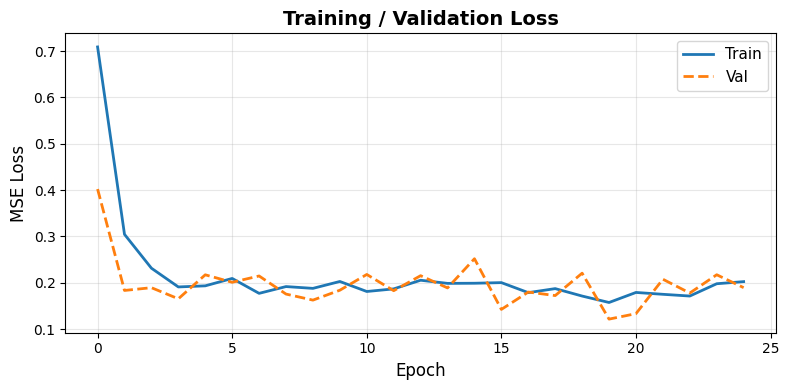

Final train loss: 0.2026


In [37]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_history,     linewidth=2, label='Train')
ax.plot(val_loss_history, linewidth=2, label='Val',   linestyle='--')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('Training / Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Final train loss: {loss_history[-1]:.4f}")


---
## 8. Evaluation

Test the planner with and without constraint projection.

In [38]:
# ── Unicycle dynamics + rollout for evaluation ────────────────────────────────
eval_dyn    = UnicycleDynamics(dt=config['dt'],
                               v_max=config['v_max'], w_max=config['w_max'])
eval_rollout = DifferentiableRollout(eval_dyn)
grid_sdf    = GridSDF2D(map_size_m=config['map_size_m'])

# ── Constraint function ───────────────────────────────────────────────────────
constraint_fn = ConstraintFunction(
    dynamics        = eval_dyn,
    grid_sdf        = grid_sdf,
    delta           = DELTA,
    goal_weight     = 50.0,
    theta_weight    = 5.0,
    obstacle_weight = 200.0,
    control_weight  = 0.1,
    smooth_weight   = 1.0,
)

# ── Proximal projection ───────────────────────────────────────────────────────
projection = ProximalProjection(
    constraint_fn,
    lambda_penalty = 0.5,
    num_steps      = 6,
    lr             = 0.05,
    v_clip         = config['v_max'],
    w_clip         = config['w_max'],
)

# ── Full sampler ──────────────────────────────────────────────────────────────
map_encoder.eval()
diffusion_model.eval()
sampler = FeasibleDiffusionSampler(
    diffusion_model  = diffusion_model,
    map_encoder      = map_encoder,
    proximal_projection = projection,
    project_every    = 5,
)

print("✓ Evaluation setup complete")


✓ Evaluation setup complete


In [39]:
# ── Evaluation helpers ─────────────────────────────────────────────────────────

@torch.no_grad()
def evaluate_controls(controls_phys, x0_phys, x_goal_phys, sdf_raw,
                       goal_tol=None):
    """All tensors: [B, ...].  Returns metrics dict."""
    goal_tol = goal_tol or config['goal_pos_tol']
    states    = eval_rollout(x0_phys, controls_phys)          # [B,T+1,3]
    positions = states[..., :2]                                # [B,T+1,2]
    final_pos = positions[:, -1]                               # [B,2]
    goal_pos  = x_goal_phys[..., :2]

    goal_err   = torch.norm(final_pos - goal_pos, dim=-1)     # [B]
    sdf_vals   = grid_sdf(sdf_raw, positions)                  # [B,T+1]
    min_clear  = sdf_vals.min(dim=1).values                   # [B]
    collision  = min_clear < ROBOT_RADIUS
    success    = (goal_err < goal_tol) & ~collision
    return {
        'success_rate':  success.float().mean().item(),
        'collision_rate':collision.float().mean().item(),
        'avg_goal_error':goal_err.mean().item(),
        'states':        states,
    }


@torch.no_grad()
def sample_diffusion(x0_phys, xg_phys, sdf_raw, T, K=32, method='ddim', eta=0.2):
    """Sample K candidates from the diffusion model; pick lowest-cost one."""
    B   = x0_phys.shape[0]
    x0n = norm_state(x0_phys)
    xgn = norm_state(xg_phys)
    sfn = sdf_raw / (MAP_SIZE_M / 2)

    # Repeat for K candidates
    x0n_r  = x0n.unsqueeze(1).expand(B, K, 3).reshape(B*K, 3)
    xgn_r  = xgn.unsqueeze(1).expand(B, K, 3).reshape(B*K, 3)
    sfn_r  = sfn.unsqueeze(1).expand(B, K, *sfn.shape[1:]).reshape(B*K, *sfn.shape[1:])
    x0p_r  = x0_phys.unsqueeze(1).expand(B, K, 3).reshape(B*K, 3)
    xgp_r  = xg_phys.unsqueeze(1).expand(B, K, 3).reshape(B*K, 3)
    sfraw_r= sdf_raw.unsqueeze(1).expand(B, K, *sdf_raw.shape[1:]).reshape(B*K, *sdf_raw.shape[1:])

    me   = map_encoder(sfn_r)
    cond = torch.cat([x0n_r, xgn_r, me], dim=-1)
    u_norm = diffusion_model.sample((B*K, T, config['control_dim']), cond,
                                    method=method, eta=eta)
    u_phys  = denorm_ctrl(u_norm)
    u_phys[:, :, 0].clamp_(-0.2, config['v_max'])
    u_phys[:, :, 1].clamp_(-config['w_max'], config['w_max'])

    costs = constraint_fn(u_phys, x0p_r, xgp_r, sdf_grid=sfraw_r).view(B, K)
    best  = torch.argmin(costs, dim=1)
    u_all = u_phys.view(B, K, T, 2)
    return u_all[torch.arange(B, device=u_phys.device), best]


@torch.no_grad()
def random_shooting(x0_phys, xg_phys, sdf_raw, T, K=256, sigma=0.8):
    B       = x0_phys.shape[0]
    u_nom   = (xg_phys[:, :2] - x0_phys[:, :2]) / (config['dt'] * T)
    u_nom   = u_nom.unsqueeze(1).unsqueeze(2).expand(B, K, T, 2)
    eps     = sigma * torch.randn(B, K, T, 2, device=x0_phys.device)
    u_cand  = torch.clamp(u_nom + eps, -3.0, 3.0)

    x0r = x0_phys.unsqueeze(1).expand(B, K, 3).reshape(B*K, 3)
    xgr = xg_phys.unsqueeze(1).expand(B, K, 3).reshape(B*K, 3)
    sfr = sdf_raw.unsqueeze(1).expand(B, K, *sdf_raw.shape[1:]).reshape(B*K, *sdf_raw.shape[1:])

    costs = constraint_fn(u_cand.reshape(B*K, T, 2), x0r, xgr, sdf_grid=sfr).view(B, K)
    best  = torch.argmin(costs, dim=1)
    return u_cand[torch.arange(B, device=x0_phys.device), best]


@torch.no_grad()
def mppi(x0_phys, xg_phys, sdf_raw, T, K=256, n_iters=10, lam=1.0, sigma=0.6):
    B  = x0_phys.shape[0]
    u  = (xg_phys[:, :2] - x0_phys[:, :2]) / (config['dt'] * T)
    u  = u.unsqueeze(1).expand(B, T, 2).clone()

    for _ in range(n_iters):
        eps    = sigma * torch.randn(B, K, T, 2, device=x0_phys.device)
        u_cand = torch.clamp(u.unsqueeze(1) + eps, -3.0, 3.0)

        x0r = x0_phys.unsqueeze(1).expand(B, K, 3).reshape(B*K, 3)
        xgr = xg_phys.unsqueeze(1).expand(B, K, 3).reshape(B*K, 3)
        sfr = sdf_raw.unsqueeze(1).expand(B, K, *sdf_raw.shape[1:]).reshape(B*K, *sdf_raw.shape[1:])

        J   = constraint_fn(u_cand.reshape(B*K,T,2), x0r, xgr, sdf_grid=sfr).view(B,K)
        w   = torch.softmax(-(J - J.min(1,keepdim=True).values) / max(lam, 1e-8), dim=1)
        u   = u + (w.unsqueeze(-1).unsqueeze(-1) * eps).sum(dim=1)
        u   = torch.clamp(u, -3.0, 3.0)

    return u


print("✓ Baseline functions defined")


✓ Baseline functions defined


In [40]:
# ── Quick comparison on one test batch ────────────────────────────────────────
tbatch = next(iter(DataLoader(test_dataset, batch_size=32, collate_fn=collate_fn)))

x0p  = tbatch['start_raw'].to(device)   # [B, 3] physical
xgp  = tbatch['goal_raw'].to(device)    # [B, 3] physical
sfr  = tbatch['sdf_raw'].to(device)     # [B, H, W]
T    = config['horizon']
C    = config['control_dim']

# Diffusion (no projection)
u_diff = sample_diffusion(x0p, xgp, sfr, T, K=32)
m_diff = evaluate_controls(u_diff, x0p, xgp, sfr)

# Diffusion + projection
u_proj, _ = sampler.sample(len(x0p), T, x0p, xgp, sfr)
m_proj    = evaluate_controls(u_proj, x0p, xgp, sfr)

# Random shooting
u_shoot = random_shooting(x0p, xgp, sfr, T)
m_shoot = evaluate_controls(u_shoot, x0p, xgp, sfr)

# MPPI
u_mppi  = mppi(x0p, xgp, sfr, T)
m_mppi  = evaluate_controls(u_mppi, x0p, xgp, sfr)

print("Quick comparison (one test batch, n=32):")
for name, m in [
    ("Diffusion (no proj)",     m_diff),
    ("Diffusion + projection",  m_proj),
    ("Random shooting K=256",   m_shoot),
    ("MPPI 10 iters K=256",     m_mppi),
]:
    print(f"  {name:28s}  "
          f"success={100*m['success_rate']:.1f}%  "
          f"collision={100*m['collision_rate']:.1f}%  "
          f"goal_err={m['avg_goal_error']:.3f} m")


Quick comparison (one test batch, n=32):
  Diffusion (no proj)           success=3.1%  collision=25.0%  goal_err=2.593 m
  Diffusion + projection        success=46.9%  collision=3.1%  goal_err=0.376 m
  Random shooting K=256         success=6.2%  collision=15.6%  goal_err=3.030 m
  MPPI 10 iters K=256           success=15.6%  collision=18.8%  goal_err=0.589 m


In [41]:
# ── Single representative test case ──────────────────────────────────────────
# Pick a test sample from the test split
_s = test_dataset[0]
x0p_s  = _s['start_raw'].unsqueeze(0).to(device)   # [1,3]
xgp_s  = _s['goal_raw'].unsqueeze(0).to(device)    # [1,3]
sfr_s  = _s['sdf_raw'].unsqueeze(0).to(device)     # [1,H,W]

print("Planning WITHOUT projection …")
x0n_s  = norm_state(x0p_s)
xgn_s  = norm_state(xgp_s)
sfn_s  = sfr_s / (MAP_SIZE_M / 2)
me_s   = map_encoder(sfn_s)
cond_s = torch.cat([x0n_s, xgn_s, me_s], dim=-1)
u_raw  = diffusion_model.sample((1, config['horizon'], 2), cond_s)
u_noproj = denorm_ctrl(u_raw)
states_noproj = eval_rollout(x0p_s, u_noproj)

print("Planning WITH projection …")
u_proj_s, _ = sampler.sample(1, config['horizon'], x0p_s, xgp_s, sfr_s)
states_proj  = eval_rollout(x0p_s, u_proj_s)

print("✓ Both trajectories generated")


Planning WITHOUT projection …
Planning WITH projection …
✓ Both trajectories generated


---
## 9. Visualization

Compare trajectories with and without constraint projection.

In [42]:
def evaluate_trajectory(states_t, x_goal_t, sdf_raw_t, name):
    """Single-sample evaluation (tensors [1,T+1,3] / [1,3] / [1,H,W])."""
    final_pos  = states_t[0, -1, :2]
    goal_pos   = x_goal_t[0, :2]
    goal_err   = torch.norm(final_pos - goal_pos).item()

    positions  = states_t[0, :, :2]          # [T+1, 2]
    sdf_vals   = grid_sdf(sdf_raw_t, positions.unsqueeze(0)).squeeze(0)
    min_clear  = sdf_vals.min().item()
    collision  = min_clear < ROBOT_RADIUS
    success    = (goal_err < config['goal_pos_tol']) and not collision

    print(f"\n{name}:")
    print(f"  Goal error:    {goal_err:.4f} m  (tol={config['goal_pos_tol']} m)")
    print(f"  Min clearance: {min_clear:.4f} m  (robot_r={ROBOT_RADIUS} m)")
    print(f"  Collision:     {collision}")
    print(f"  Success:       {success}")
    return states_t[0].cpu().numpy(), goal_err, collision, success

sno, eno, cno, sno_ok  = evaluate_trajectory(states_noproj, xgp_s, sfr_s, "Without projection")
sye, eye, cye, sye_ok  = evaluate_trajectory(states_proj,   xgp_s, sfr_s, "With projection")



Without projection:
  Goal error:    17.3267 m  (tol=0.3 m)
  Min clearance: -0.2294 m  (robot_r=0.2 m)
  Collision:     True
  Success:       False

With projection:
  Goal error:    1.1944 m  (tol=0.3 m)
  Min clearance: 1.1994 m  (robot_r=0.2 m)
  Collision:     False
  Success:       False


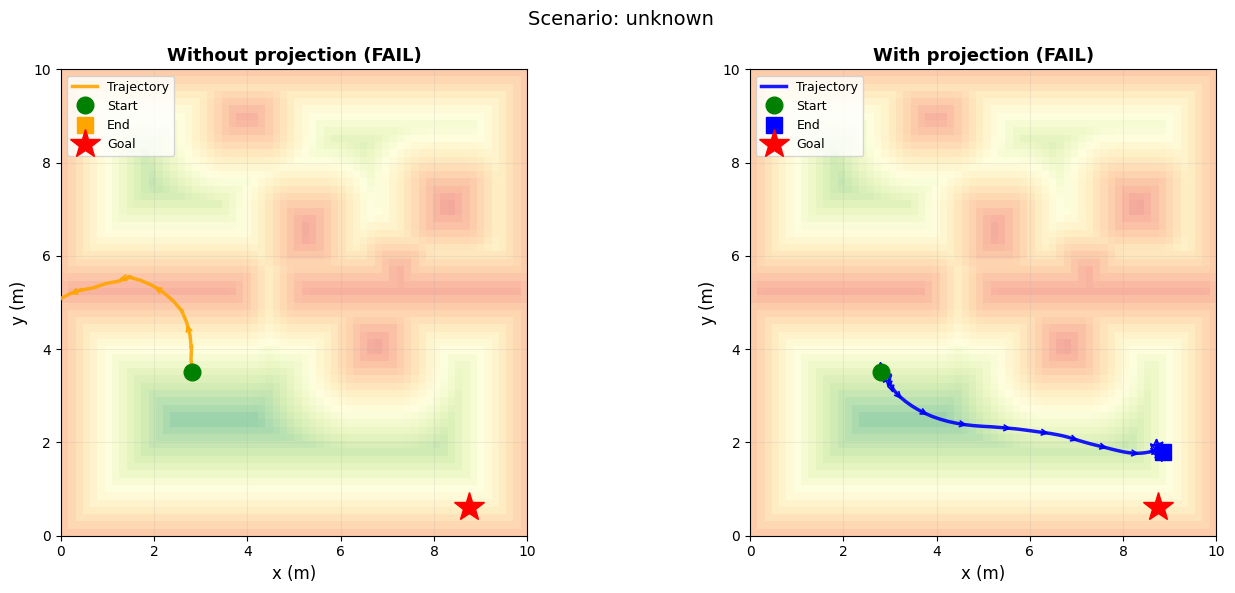


Note: single-case plot is illustrative; refer to batch statistics below.


In [43]:
# ── Visualise on the 64×64 SDF map ───────────────────────────────────────────
sdf_np = sfr_s[0].cpu().numpy()   # [H, W]
occ_np = (_s['sdf_raw'].numpy() < ROBOT_RADIUS).astype(np.float32)  # binary occupied

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, (states_np, title, color, success) in enumerate([
    (sno, 'Without projection', 'orange', sno_ok),
    (sye, 'With projection',    'blue',   sye_ok),
]):
    ax = axes[i]

    # SDF background
    ax.imshow(sdf_np, origin='lower', extent=[0, MAP_SIZE_M, 0, MAP_SIZE_M],
              cmap='RdYlGn', vmin=-1, vmax=3, alpha=0.5)

    # Trajectory
    ax.plot(states_np[:, 0], states_np[:, 1],
            color=color, linewidth=2.5, alpha=0.9, label='Trajectory', zorder=5)

    # Start / end / goal
    ax.plot(states_np[0, 0],  states_np[0, 1],  'go',  ms=12, label='Start', zorder=10)
    ax.plot(states_np[-1, 0], states_np[-1, 1],  's',
            color=color, ms=12, label='End',   zorder=10)
    ax.plot(xgp_s[0, 0].item(), xgp_s[0, 1].item(), 'r*', ms=22, label='Goal', zorder=10)

    # Heading arrows along trajectory (every 5 steps)
    for t in range(0, len(states_np), 5):
        x_, y_, th_ = states_np[t]
        ax.annotate('', xy=(x_ + 0.3*math.cos(th_), y_ + 0.3*math.sin(th_)),
                    xytext=(x_, y_),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.2), zorder=6)

    ax.set_xlim(0, MAP_SIZE_M); ax.set_ylim(0, MAP_SIZE_M)
    ax.grid(True, alpha=0.2)
    ax.legend(loc='upper left', fontsize=9)
    ax.set_xlabel('x (m)', fontsize=12); ax.set_ylabel('y (m)', fontsize=12)
    ax.set_aspect('equal')
    status = 'SUCCESS' if success else 'FAIL'
    ax.set_title(f'{title} ({status})', fontsize=13, fontweight='bold')

plt.suptitle(f"Scenario: {str(_s.get('scenario_type', 'unknown') if hasattr(_s,'get') else 'test')}",
             fontsize=14)
plt.tight_layout()
plt.show()
print("\nNote: single-case plot is illustrative; refer to batch statistics below.")


---
## 10. Batch Evaluation

Evaluate on 800 random test problems (maps sampled from dataset.py pipeline).

In [ ]:
NUM_TEST = 800
GOAL_TOL = config['goal_pos_tol']

results_no_proj   = []
results_with_proj = []
times_no, times_with = [], []

# ── Sample test cases directly from the saved test split ─────────────────────
# (avoids re-running dataset.py / CEM at evaluation time)
_test_files = sorted(glob.glob(os.path.join(DATA_DIR, 'test', '*.npz')))
if not _test_files:
    # fall back to val split if test is small
    _test_files = sorted(glob.glob(os.path.join(DATA_DIR, 'val', '*.npz')))
print(f"Test pool: {len(_test_files)} files  (will sample with replacement if needed)")

def _sample_test_case():
    """Return (x0_phys [1,3], xg_phys [1,3], sdf_raw [1,H,W]) from saved test split."""
    f   = random.choice(_test_files)
    d   = np.load(f, allow_pickle=True)
    x0t = torch.tensor(np.array(d['start']), dtype=torch.float32).unsqueeze(0)
    xgt = torch.tensor(np.array(d['goal']),  dtype=torch.float32).unsqueeze(0)
    sfrt= torch.tensor(np.array(d['sdf']),   dtype=torch.float32).unsqueeze(0)
    return x0t, xgt, sfrt

def _tic():
    if device.type == 'cuda': torch.cuda.synchronize()
    return time.perf_counter()
def _toc(t0):
    if device.type == 'cuda': torch.cuda.synchronize()
    return time.perf_counter() - t0

print(f"Evaluating on {NUM_TEST} test cases …\n")
t_total_start = _tic()

for i in tqdm_nb(range(NUM_TEST), desc="Batch eval"):
    x0p, xgp, sfr_raw = _sample_test_case()
    x0p     = x0p.to(device)
    xgp     = xgp.to(device)
    sfr_raw = sfr_raw.to(device)

    # ── Without projection (diffusion best-of-16) ───────────────────────────
    t0 = _tic()
    u_np  = sample_diffusion(x0p, xgp, sfr_raw, config['horizon'], K=16)
    st_np = eval_rollout(x0p, u_np)
    dt_no = _toc(t0)
    times_no.append(dt_no)

    fp_no  = st_np[0, -1, :2]
    ge_no  = torch.norm(fp_no - xgp[0, :2]).item()
    sv_no  = grid_sdf(sfr_raw, st_np[..., :2])
    col_no = (sv_no.min() < ROBOT_RADIUS).item()
    results_no_proj.append({
        'goal_error': ge_no, 'collision': col_no,
        'success': ge_no < GOAL_TOL and not col_no, 'time_s': dt_no,
    })

    # ── With projection ──────────────────────────────────────────────────────
    t0 = _tic()
    u_p, _ = sampler.sample(1, config['horizon'], x0p, xgp, sfr_raw)
    st_p   = eval_rollout(x0p, u_p)
    dt_wi  = _toc(t0)
    times_with.append(dt_wi)

    fp_wi  = st_p[0, -1, :2]
    ge_wi  = torch.norm(fp_wi - xgp[0, :2]).item()
    sv_wi  = grid_sdf(sfr_raw, st_p[..., :2])
    col_wi = (sv_wi.min() < ROBOT_RADIUS).item()
    results_with_proj.append({
        'goal_error': ge_wi, 'collision': col_wi,
        'success': ge_wi < GOAL_TOL and not col_wi, 'time_s': dt_wi,
    })

t_total = _toc(t_total_start)
print(f"\n✓  Done in {t_total:.1f}s")


In [ ]:
def compute_stats(results, name):
    suc  = np.array([r['success']    for r in results], dtype=np.float64)
    col  = np.array([r['collision']  for r in results], dtype=np.float64)
    gerr = np.array([r['goal_error'] for r in results], dtype=np.float64)
    ts   = np.array([r['time_s']     for r in results], dtype=np.float64)
    n    = len(results)
    return {
        'name':           name,
        'n':              n,
        'success_rate':   suc.mean() * 100,
        'collision_rate': col.mean() * 100,
        'avg_goal_error': gerr.mean(),
        'se_success':     math.sqrt(max(suc.mean()*(1-suc.mean()), 1e-9)/n)*100,
        'se_collision':   math.sqrt(max(col.mean()*(1-col.mean()), 1e-9)/n)*100,
        'se_goal':        (gerr.std(ddof=1)/math.sqrt(n)) if n > 1 else 0,
        'avg_time_ms':    ts.mean() * 1000,
        'se_time_ms':     (ts.std(ddof=1)/math.sqrt(n))*1000 if n>1 else 0,
    }

stats_no  = compute_stats(results_no_proj,   "Diffusion only")
stats_yes = compute_stats(results_with_proj, "Our method (+ projection)")

print("\nBatch results:")
for s in [stats_no, stats_yes]:
    print(f"\n{s['name']} (n={s['n']}):")
    print(f"  Success rate:   {s['success_rate']:.1f}% ± {s['se_success']:.1f}%")
    print(f"  Collision rate: {s['collision_rate']:.1f}% ± {s['se_collision']:.1f}%")
    print(f"  Avg goal error: {s['avg_goal_error']:.3f} m ± {s['se_goal']:.3f} m")
    print(f"  Avg time:       {s['avg_time_ms']:.1f} ms ± {s['se_time_ms']:.1f} ms")


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ['success_rate', 'collision_rate', 'avg_goal_error']
titles  = ['Success rate (%)', 'Collision rate (%)', 'Avg goal error (m)']
colors  = ['green', 'red', 'blue']
se_keys = ['se_success', 'se_collision', 'se_goal']

for ax, metric, title, color, se_key in zip(axes, metrics, titles, colors, se_keys):
    labels = ['Diffusion\nonly', '+ Projection']
    vals   = [stats_no[metric], stats_yes[metric]]
    yerr   = [stats_no[se_key], stats_yes[se_key]]
    bars   = ax.bar(labels, vals, color=color, edgecolor='black', linewidth=1.5,
                    alpha=[0.5, 1.0])
    ax.errorbar([0,1], vals, yerr=yerr, fmt='none', capsize=6, color='black')
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height(),
                f'{v:.1f}{"%" if "rate" in metric else " m"}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


---
## 11. Ablation Study: Projection Penalty λ

In [ ]:
lambda_values   = [0.01, 0.05, 0.1, 0.5, 1.0]
abl_lambda_res  = []
N_ABL = 50

print("Running λ ablation …")
for lam in lambda_values:
    proj_tmp = ProximalProjection(constraint_fn, lambda_penalty=lam,
                                  num_steps=6, lr=0.05,
                                  v_clip=config['v_max'], w_clip=config['w_max'])
    smp_tmp = FeasibleDiffusionSampler(diffusion_model, map_encoder, proj_tmp,
                                       project_every=5)
    succs, cols, gerrs = [], [], []
    for _ in range(N_ABL):
        x0t, xgt, sfrt = _sample_test_case()
        x0t = x0t.to(device); xgt = xgt.to(device); sfrt = sfrt.to(device)
        u_, _ = smp_tmp.sample(1, config['horizon'], x0t, xgt, sfrt)
        st_   = eval_rollout(x0t, u_)
        fp_   = st_[0,-1,:2]
        ge_   = torch.norm(fp_ - xgt[0,:2]).item()
        sv_   = grid_sdf(sfrt, st_[..., :2])
        col_  = (sv_.min() < ROBOT_RADIUS).item()
        succs.append(ge_ < GOAL_TOL and not col_)
        cols.append(col_); gerrs.append(ge_)
    abl_lambda_res.append({
        'lambda': lam,
        'success_rate':   np.mean(succs)*100,
        'collision_rate': np.mean(cols)*100,
        'avg_goal_error': float(np.mean(gerrs)),
    })
    print(f"  λ={lam:.3f}  success={abl_lambda_res[-1]['success_rate']:.1f}%  "
          f"collision={abl_lambda_res[-1]['collision_rate']:.1f}%")
print("✓ λ ablation done")


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
lams = [r['lambda']         for r in abl_lambda_res]
succ = [r['success_rate']   for r in abl_lambda_res]
coll = [r['collision_rate'] for r in abl_lambda_res]
ax.plot(lams, succ, 'o-', lw=2, ms=10, label='Success Rate',   color='green')
ax.plot(lams, coll, 's-', lw=2, ms=10, label='Collision Rate', color='red')
ax.set_xscale('log')
ax.set_xlabel('Lambda (λ)', fontsize=13)
ax.set_ylabel('Rate (%)',   fontsize=13)
ax.set_title('Ablation: Effect of Lambda on Performance', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()
best_lam = abl_lambda_res[np.argmax(succ)]['lambda']
print(f"Best λ: {best_lam}")


---
## 12. Extended Ablations: Temporal Correlation × Projection Frequency

- **Temporal correlation** (AR(1) parameter `rho`): smoothness of injected noise
- **Projection frequency** (`project_every`): how often the proximal step is applied


In [ ]:
import pandas as pd

def ar1_noise(x: torch.Tensor, rho: float) -> torch.Tensor:
    """AR(1) noise along horizon dim; marginal variance ≈ 1 for any rho in [0,1)."""
    if rho <= 0.0:
        return torch.randn_like(x)
    B, T, C = x.shape
    eps = torch.randn(B, T, C, device=x.device, dtype=x.dtype)
    out = torch.empty_like(eps)
    out[:, 0, :] = eps[:, 0, :]
    scale = math.sqrt(1.0 - rho * rho)
    for t in range(1, T):
        out[:, t, :] = rho * out[:, t-1, :] + scale * eps[:, t, :]
    return out


@torch.no_grad()
def p_sample_ar1(diff_model, u_k, k, condition, rho=0.0):
    """DDPM reverse step with AR(1) noise."""
    eps = diff_model.denoiser(u_k, k, condition)
    abar   = diff_model.alphas_cumprod[k][:,None,None]
    alpha  = diff_model.alphas[k][:,None,None]
    beta   = diff_model.betas[k][:,None,None]
    u0hat  = (u_k - torch.sqrt(1-abar)*eps) / torch.sqrt(abar)
    abar_p = torch.where((k>0)[:,None,None],
                         diff_model.alphas_cumprod[(k-1).clamp(min=0)][:,None,None],
                         torch.ones_like(abar))
    sigma  = torch.sqrt(beta * (1-abar_p) / (1-abar))
    coef1  = torch.sqrt(abar_p) * beta / (1-abar)
    coef2  = torch.sqrt(alpha) * (1-abar_p) / (1-abar)
    mu     = coef1*u0hat + coef2*u_k
    return mu + (k>0)[:,None,None].float() * sigma * ar1_noise(u_k, rho)


def eval_cfg(noise_rho, project_every, n_test=150, seed=0):
    """Evaluate one (rho, project_every) configuration."""
    rng_state = random.getstate(); np_state = np.random.get_state()
    random.seed(seed); np.random.seed(seed)

    proj_e = ProximalProjection(constraint_fn, lambda_penalty=best_lam,
                                num_steps=6, lr=0.05,
                                v_clip=config['v_max'], w_clip=config['w_max'])
    succs, cols, gerrs, smooths = [], [], [], []

    for _ in range(n_test):
        x0t, xgt, sfrt = _sample_test_case()
        x0t  = x0t.to(device); xgt = xgt.to(device); sfrt = sfrt.to(device)
        B    = 1; T = config['horizon']; C = config['control_dim']
        x0n  = norm_state(x0t);  xgn = norm_state(xgt)
        sfn  = sfrt / (MAP_SIZE_M / 2)
        me_  = map_encoder(sfn)
        cond = torch.cat([x0n, xgn, me_], dim=-1)

        u_n  = torch.randn(B, T, C, device=device)
        for i in reversed(range(diffusion_model.T_diffusion)):
            kt = torch.full((B,), i, device=device, dtype=torch.long)
            u_n = p_sample_ar1(diffusion_model, u_n, kt, cond, rho=noise_rho)
            if project_every is not None and (i % project_every == 0):
                u_ph = denorm_ctrl(u_n)
                with torch.enable_grad():
                    u_ph, _ = proj_e.project(u_ph, x0t, xgt, sdf_grid=sfrt)
                u_n = norm_ctrl(u_ph)

        u_phys = denorm_ctrl(u_n)
        st_ = eval_rollout(x0t, u_phys)
        fp_ = st_[0,-1,:2]
        ge_ = torch.norm(fp_ - xgt[0,:2]).item()
        sv_ = grid_sdf(sfrt, st_[..., :2])
        col_= (sv_.min() < ROBOT_RADIUS).item()
        sm_ = float(((u_phys[:,1:]-u_phys[:,:-1])**2).mean().item())
        succs.append(ge_<GOAL_TOL and not col_)
        cols.append(col_); gerrs.append(ge_); smooths.append(sm_)

    n = n_test
    random.setstate(rng_state); np.random.set_state(np_state)
    return {
        'n': n,
        'success_rate':   np.mean(succs)*100,
        'collision_rate': np.mean(cols)*100,
        'avg_goal_error': float(np.mean(gerrs)),
        'avg_smooth':     float(np.mean(smooths)),
        'se_success':     math.sqrt(max(np.mean(succs)*(1-np.mean(succs)),1e-9)/n)*100,
        'se_collision':   math.sqrt(max(np.mean(cols)*(1-np.mean(cols)),1e-9)/n)*100,
        'se_goal':        float(np.std(gerrs,ddof=1)/math.sqrt(n)),
        'se_smooth':      float(np.std(smooths,ddof=1)/math.sqrt(n)),
    }

print("✓ Extended ablation utilities ready")


In [ ]:
ABL_N      = 150
rhos       = [0.0, 0.8, 0.95]
proj_every = [None, 20, 10, 5, 2, 1]

abl_rows = []
for rho in rhos:
    for pe in proj_every:
        print(f"  rho={rho}  proj_every={pe} …", end=' ', flush=True)
        s = eval_cfg(rho, pe, n_test=ABL_N,
                     seed=1000 + int(100*rho) + (0 if pe is None else int(pe)))
        abl_rows.append({
            'noise_rho': rho,
            'project_every': 'none' if pe is None else pe,
            **s,
        })
        print(f"success={s['success_rate']:.1f}%")

abl_df = pd.DataFrame(abl_rows)
abl_df.to_csv('ablations_temporal_projfreq.csv', index=False)
display(abl_df.sort_values(['noise_rho','project_every'], ascending=[True,False]))
print("\nSaved: ablations_temporal_projfreq.csv")


In [ ]:
order = ['none', 20, 10, 5, 2, 1]
fig, ax = plt.subplots(figsize=(8, 4))
for rho in rhos:
    sub = abl_df[abl_df['noise_rho'] == rho].copy()
    sub['ord'] = sub['project_every'].apply(lambda x: order.index(x))
    sub = sub.sort_values('ord')
    ax.errorbar(sub['ord'], sub['success_rate'], yerr=sub['se_success'],
                marker='o', label=f'rho={rho}')
ax.set_xticks(range(len(order)), order)
ax.set_xlabel('Projection frequency (every k diffusion steps)')
ax.set_ylabel('Success rate (%)')
ax.set_title('Ablation: Temporal correlation vs projection frequency')
ax.legend()
plt.tight_layout()
plt.savefig('ablation_success_vs_projfreq.png', dpi=200)
plt.show()
print("Saved: ablation_success_vs_projfreq.png")


---
## 13. Scenario Sweep: Map Complexity × Horizon

Compare **diffusion only** vs **diffusion + projection** across:
- Map types: `open`, `clutter`, `corridor`, `doorway`, `parking`
- Horizon lengths: `config['horizon']`, and 1.5× and 2×


In [ ]:
import pandas as pd

# ── Build per-scenario test pools from ALL saved splits ──────────────────────
_all_files = (sorted(glob.glob(os.path.join(DATA_DIR, 'train', '*.npz')))
            + sorted(glob.glob(os.path.join(DATA_DIR, 'val',   '*.npz')))
            + sorted(glob.glob(os.path.join(DATA_DIR, 'test',  '*.npz'))))

_scenario_files = {}
print("Indexing scenario types …")
for _fp in _all_files:
    _d = np.load(_fp, allow_pickle=True)
    _sc = str(_d['scenario_type'])
    _scenario_files.setdefault(_sc, []).append(_fp)

for sc, flist in _scenario_files.items():
    print(f"  {sc}: {len(flist)} files")

ALL_SCENARIOS = list(_scenario_files.keys())

def _sample_typed_file(scenario_type):
    """Sample one (x0, xgoal, sdf) from the saved files for a given scenario type."""
    files = _scenario_files.get(scenario_type, [])
    if not files:
        return None
    f   = random.choice(files)
    d   = np.load(f, allow_pickle=True)
    x0t = torch.tensor(np.array(d['start']), dtype=torch.float32).unsqueeze(0)
    xgt = torch.tensor(np.array(d['goal']),  dtype=torch.float32).unsqueeze(0)
    sfrt= torch.tensor(np.array(d['sdf']),   dtype=torch.float32).unsqueeze(0)
    return x0t, xgt, sfrt

SCEN_N    = 100
horizons  = [config['horizon']]          # extend if you want multi-horizon sweep
BEST_PROJ = 2
BEST_RHO  = 0.0

scen_rows = []
for mtype in ALL_SCENARIOS:
    for T_eval in horizons:
        for pe in [None, BEST_PROJ]:
            proj_s = ProximalProjection(constraint_fn, lambda_penalty=best_lam,
                                        num_steps=6, lr=0.05,
                                        v_clip=config['v_max'], w_clip=config['w_max'])
            succs, cols = [], []
            for _ in range(SCEN_N):
                res = _sample_typed_file(mtype)
                if res is None: continue
                x0t, xgt, sfrt = [r.to(device) for r in res]
                if pe is None:
                    u_ = sample_diffusion(x0t, xgt, sfrt, T_eval, K=16)
                else:
                    smp_s = FeasibleDiffusionSampler(diffusion_model, map_encoder,
                                                     proj_s, project_every=pe)
                    u_, _ = smp_s.sample(1, T_eval, x0t, xgt, sfrt)
                st_ = eval_rollout(x0t, u_)
                ge_ = torch.norm(st_[0,-1,:2] - xgt[0,:2]).item()
                col_= (grid_sdf(sfrt, st_[...,:2]).min() < ROBOT_RADIUS).item()
                succs.append(ge_ < GOAL_TOL and not col_)
                cols.append(col_)
            n_ok = max(len(succs), 1)
            se_s = math.sqrt(max(np.mean(succs)*(1-np.mean(succs)), 1e-9) / n_ok) * 100
            scen_rows.append({
                'map_type':      mtype,
                'horizon':       T_eval,
                'project_every': 'none' if pe is None else pe,
                'success_rate':  np.mean(succs) * 100,
                'se_success':    se_s,
                'collision_rate':np.mean(cols) * 100,
            })
            print(f"  {mtype:10s}  T={T_eval:3d}  pe={str(pe):4s}  "
                  f"success={scen_rows[-1]['success_rate']:.1f}%")

sc_df = pd.DataFrame(scen_rows)
sc_df.to_csv('scenario_sweep.csv', index=False)
display(sc_df)


In [ ]:
df_p = sc_df.copy()
df_p['label'] = df_p.apply(lambda r: f"{r['map_type']},T{int(r['horizon'])}", axis=1)
labels = sorted(df_p['label'].unique())
x = np.arange(len(labels)); width=0.35

no_  = df_p[df_p['project_every']=='none'].set_index('label').reindex(labels)
yes_ = df_p[df_p['project_every']==BEST_PROJ].set_index('label').reindex(labels)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(x-width/2, no_['success_rate'].fillna(0).values,  width,
       yerr=no_['se_success'].fillna(0).values,  label='No projection')
ax.bar(x+width/2, yes_['success_rate'].fillna(0).values, width,
       yerr=yes_['se_success'].fillna(0).values, label=f'Proj every {BEST_PROJ}')
ax.set_xticks(x, labels, rotation=45, ha='right')
ax.set_ylabel('Success rate (%)')
ax.set_title(f'Scenario sweep (noise_rho={BEST_RHO})')
ax.legend(); plt.tight_layout()
plt.savefig('scenario_sweep_success.png', dpi=200)
plt.show()


---
## 14. Report Export: LaTeX Table + Summary

In [ ]:
def fmt_pm(mu, se, d=1):
    return f"{mu:.{d}f} $\\pm$ {se:.{d}f}"

order_pe = ['none', 20, 10, 5, 2, 1]
df_tab   = abl_df.copy()
df_tab['ord'] = df_tab['project_every'].apply(lambda x: order_pe.index(x))
df_tab = df_tab.sort_values(['noise_rho', 'ord'])

lines = [
    r"\begin{table}[t]",
    r"\centering",
    r"\caption{Ablation on temporal correlation ($\rho$) and projection frequency. "
    r"Mean $\pm$ SE over $n=" + str(ABL_N) + r"$ instances.}",
    r"\label{tab:ablations}",
    r"\begin{tabular}{lccc}",
    r"\toprule",
    r"$\rho$ & proj.\ every & success (\%) & collision (\%) \\",
    r"\midrule",
]
for _, r in df_tab.iterrows():
    lines.append(
        f"{r['noise_rho']:.2f} & {r['project_every']} & "
        f"{fmt_pm(r['success_rate'],r['se_success'])} & "
        f"{fmt_pm(r['collision_rate'],r['se_collision'])} \\\\"
    )
lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]

with open('results_tables.tex', 'w') as f:
    f.write('\n'.join(lines))

# Summary table (Table 2 style)
best_idx  = df_tab['success_rate'].idxmax()
best_row  = df_tab.loc[best_idx]
with open('report_snippet.md', 'w') as f:
    f.write('### Key quantitative takeaways\n')
    f.write(f"- Dataset: **DiffDrive** (unicycle, diverse maps), horizon={HORIZON}, map=10×10 m\n")
    f.write(f"- Batch eval n={NUM_TEST}: "
            f"diffusion-only {stats_no['success_rate']:.1f}%±{stats_no['se_success']:.1f}% success; "
            f"with projection {stats_yes['success_rate']:.1f}%±{stats_yes['se_success']:.1f}% success\n")
    f.write(f"- Avg time: no-proj {stats_no['avg_time_ms']:.1f} ms, "
            f"with-proj {stats_yes['avg_time_ms']:.1f} ms\n")
    f.write(f"- Best ablation: rho={best_row['noise_rho']:.2f}, "
            f"proj_every={best_row['project_every']}, "
            f"success={best_row['success_rate']:.1f}%\n")

print('Saved: results_tables.tex')
print('Saved: report_snippet.md')


---
## 🎉 Complete!

You now have:
- ✅ A diverse DiffDrive dataset (unicycle, diverse map types, CEM-planned trajectories)
- ✅ A trained diffusion model conditioned on (start, goal, map SDF)
- ✅ Proximal projection for kinodynamic constraint satisfaction
- ✅ Evaluation metrics, visualizations, and ablation studies
- ✅ LaTeX table + markdown summary for the report

### Key design changes vs. the original notebook:
| Aspect | Original | Updated |
|---|---|---|
| Dynamics | SingleIntegrator2D `[x,y]` | UnicycleDynamics `[x,y,θ]` |
| Map | 3 fixed circles | Diverse: clutter / corridor / doorway / parking |
| SDF | Analytic circle | Per-sample 64×64 grid + bilinear interp |
| Conditioning | `[x0, xgoal]` 4-D | `[x0_norm, xgoal_norm, map_emb]` 38-D |
| Map encoder | — | Small CNN (64×64 → 32-D) |
| Planner | Gradient OCP | CEM (Cross-Entropy Method) |
| Map coordinates | `[-1, 1]` | `[0, 10]` m |
